In [1]:
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.collections import LineCollection
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from scipy.linalg import expm
from scipy.stats import multivariate_normal
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import lsmr, lsqr, spsolve, eigsh
from scipy.special import erf, iv
from mpl_toolkits.axes_grid1 import make_axes_locatable
import helpers as h
import importlib
from matplotlib.colors import LogNorm
import pandas as pd
sns.set_theme(
    font='Times New Roman',
    palette='magma',
    rc={'font.family': 'Times New Roman'},
    style = 'white',
    font_scale = 1.5
)

In [2]:
df = pd.read_csv('fish_velocities/fish_velocities_60_tr4.csv',header=None)
df.ffill(inplace=True)
traj = df.to_numpy()

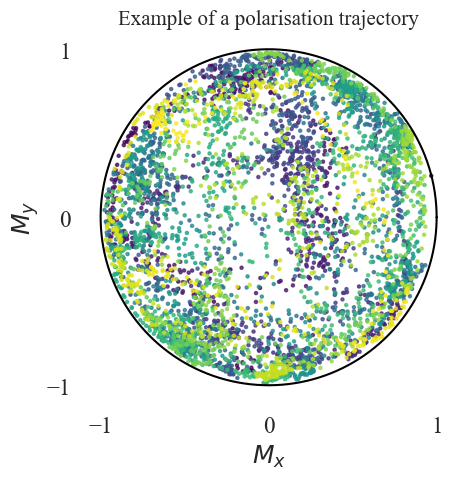

In [3]:
fig, ax = plt.subplots(1,1)
t = np.linspace(0,traj.shape[0]-1,traj.shape[0])
end = 5000
ax.scatter(traj[:end,0], traj[:end,1], alpha = 0.75, c=t[:end],cmap='viridis',s = 5)
theta = np.linspace(0,2*np.pi,1000)
x = np.cos(theta)
y = np.sin(theta)
ax.plot(x,y,'k')
ax.set_xlim([-1.1,1.1])
ax.set_ylim([-1.1,1.1])
ax.set_xticks([-1,0,1])
ax.set_yticks([-1,0,1])
ax.set_aspect('equal')
ax.set_xlabel(r'$M_x$')
ax.set_ylabel(r'$M_y$')
ax.set_title('Example of a polarisation trajectory', fontsize=15)
sns.despine(left=True, bottom = True)
#plt.savefig("polarisation1.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [38]:
dx = 0.25
time_course,out_of_domain,counts,states_idx, grid_x, grid_y, no_states, num_cells_x, num_cells_y, xmin, xmax, ymin, ymax = h.coarse_grain_trajectory(traj.T,dx,dy=dx)

tau = 0.1
L_init = h.bayesian_transition_circle_prior(no_states, states_idx, num_cells_x, num_cells_y)
L_hat = h.CT_Markov_Chain_MLE(time_course, states_idx , L_init, no_states, dt = tau, out_of_domain= out_of_domain)
p_ss = h.sparse_stationary(L_hat)

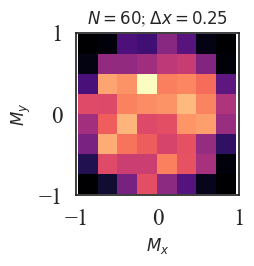

In [39]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(3,3)
im = ax.imshow(p_ss.reshape(num_cells_x,num_cells_y),origin = 'lower', extent = [xmin, xmax ,ymin, ymax],cmap = 'magma')
#h.plot_flux_normalized(J, num_cells_x, num_cells_y, (xmin, xmax), (ymin, ymax), ax[1], scale= 10)
ax.set_aspect('equal')
ax.set_xticks([-1,0,1])
ax.set_yticks([-1,0,1])
ax.set_xlabel(r'$M_x$', fontsize= 12)
ax.set_ylabel(r'$M_y$', fontsize= 12)
ax.set_title(r'$N = 60$; $\Delta x = 0.25$', fontsize =12)
plt.tight_layout()
plt.show()

Now, I will calculate the EPR for these trajectories and for their shuffled surrogates.

In [97]:
EPR_fish = np.zeros(3)

dx_range  = [0.25]
sizes = [15, 30, 60]

for j, size in enumerate(sizes):
    if size != 60:
        df = pd.read_csv(f'fish_velocities/fish_velocities_{size}_tr1.csv',header=None)
    else:
        df = pd.read_csv(f'fish_velocities/fish_velocities_{size}_tr4.csv',header=None)
    df.ffill(inplace=True)
    traj = df.to_numpy()

    time_course,out_of_domain,counts,states_idx, grid_x, grid_y, no_states, num_cells_x, num_cells_y, xmin, xmax, ymin, ymax = h.coarse_grain_trajectory(traj.T,dx,dy=dx)
    tau = 0.1
    L_init = h.bayesian_transition_circle_prior(no_states, states_idx, num_cells_x, num_cells_y)
    L_hat = h.CT_Markov_Chain_MLE(time_course, states_idx , L_init, no_states, dt = tau, out_of_domain= out_of_domain)
    p_ss = h.sparse_stationary(L_hat)
    J = h.calculate_flux_matrix(L_hat,p_ss)

    EPR_fish[j] = h.EPR_MC(L_hat,p_ss)

In [98]:
EPR_fish

array([0.03900639, 0.03582105, 0.03178454])

In [45]:
EPR_fish_shuffled = np.zeros((3,100))

dx_range  = [0.25]
sizes = [15, 30, 60]

for j, size in enumerate(sizes):
    if size != 60:
        df = pd.read_csv(f'fish_velocities/fish_velocities_{size}_tr1.csv',header=None)
    else:
        df = pd.read_csv(f'fish_velocities/fish_velocities_{size}_tr4.csv',header=None)
    df.ffill(inplace=True)
    traj = df.to_numpy()

    time_course,out_of_domain,counts,states_idx, grid_x, grid_y, no_states, num_cells_x, num_cells_y, xmin, xmax, ymin, ymax = h.coarse_grain_trajectory(traj.T,dx,dy=dx)
    tau = 0.1
    L_init = h.bayesian_transition_circle_prior(no_states, states_idx, num_cells_x, num_cells_y)

    for s in range(0,100):
        L_hat = h.CT_Markov_Chain_MLE_shuffling(time_course, states_idx , L_init, no_states, dt = tau, out_of_domain= out_of_domain)
        p_ss = h.sparse_stationary(L_hat)
    
        EPR_fish_shuffled[j, s] = h.EPR_MC(L_hat,p_ss)

        if s%10 == 0:
            print(s)

0
0
10
20
30
40
50
60
70
80
90
1
0
10
20
30
40
50
60
70
80
90
2
0
10
20
30
40
50
60
70
80
90


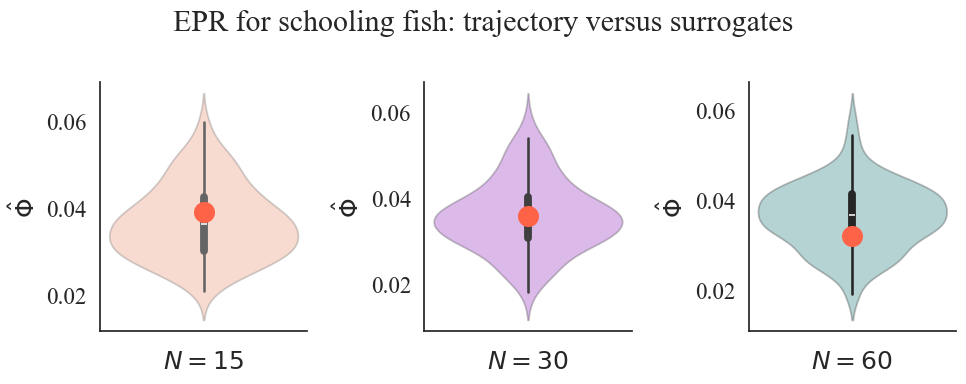

In [113]:
fig, ax = plt.subplots(1,3)
fig.set_size_inches(10,4)

colours = ['coral','darkviolet','teal']
for i in range(0,3):
    sns.violinplot(EPR_fish_shuffled[i,:], ax = ax[i], color = colours[i], alpha = 0.3)
    sns.despine(ax=ax[i])
    ax[i].scatter(0,EPR_fish[i], color = 'tomato', zorder = 100, s = 200, marker = 'o')
    ax[i].set_xlabel(r'$N = ' + str(sizes[i]) + r'$')
    ax[i].set_ylabel(r'$\hat{\Phi}$')

fig.suptitle('EPR for schooling fish: trajectory versus surrogates')
plt.tight_layout()
plt.show()

In [104]:
p_one_sided = np.mean(EPR_fish_shuffled[2,:] <= EPR_fish[2])
print(p_one_sided)

0.24


In [12]:
df = pd.read_csv('fish_velocities/fish_velocities_30_tr1.csv',header=None)
df.ffill(inplace=True)
traj = np.linalg.norm(df.to_numpy(),axis=1)

In [13]:
m_30 = np.mean(traj)
s_30 = np.std(traj)

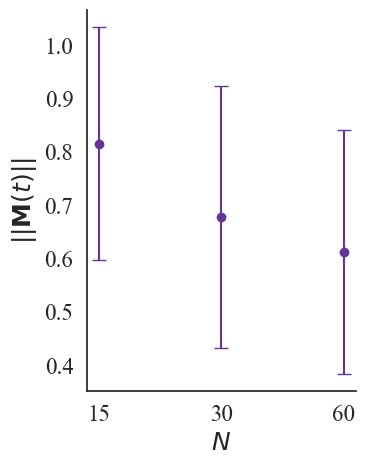

In [35]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(4,5)
x = [0, 1, 2]
y = [m_15, m_30, m_60]
yerr = [s_15, s_30, s_60]

ax.errorbar(x, y, yerr=yerr, fmt='o', elinewidth=1.5, capsize=5, color = 'rebeccapurple')
ax.set_xticks(x)
ax.set_xticklabels(['15','30','60'])
ax.set_xlabel(r'$N$')
ax.set_ylabel(r'$||\mathbf{M}(t)||$')
sns.despine()
plt.tight_layout()
plt.show()